In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub   #type:ignore
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv


In [2]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv")

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [4]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [5]:
df.shape

(6362620, 11)

In [6]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

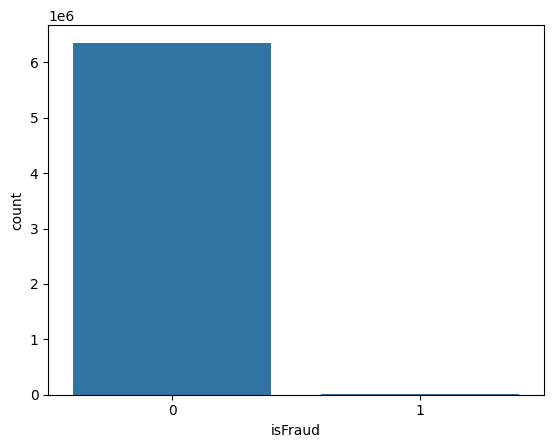

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="isFraud", data=df)

plt.show()

In [8]:
fraud_rate = df["isFraud"].mean()*100

print(f"Fraud Rate = {fraud_rate:.4f}%")

Fraud Rate = 0.1291%


In [9]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [10]:
pd.crosstab(
    df["type"],
    df["isFraud"]
)

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


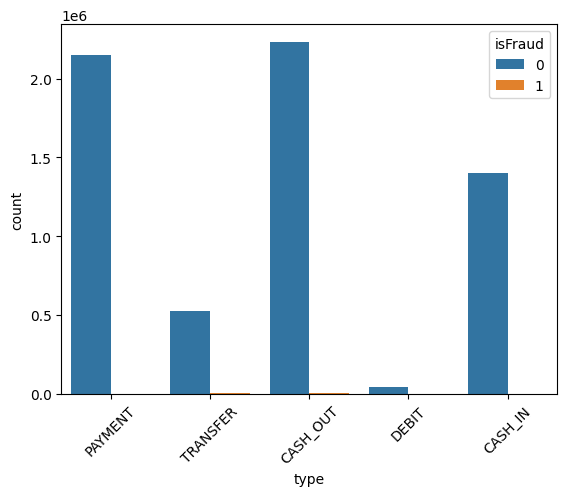

In [11]:
sns.countplot(
    x="type",
    hue="isFraud",
    data=df
)

plt.xticks(rotation=45)
plt.show()

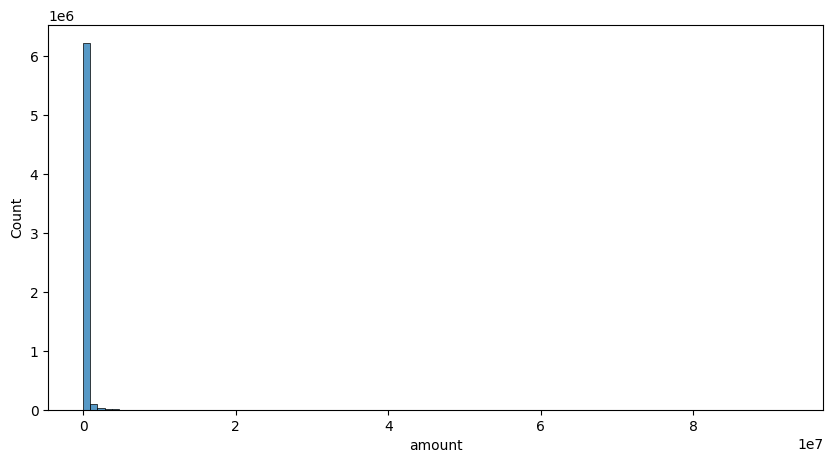

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["amount"],
    bins=100
)

plt.show()

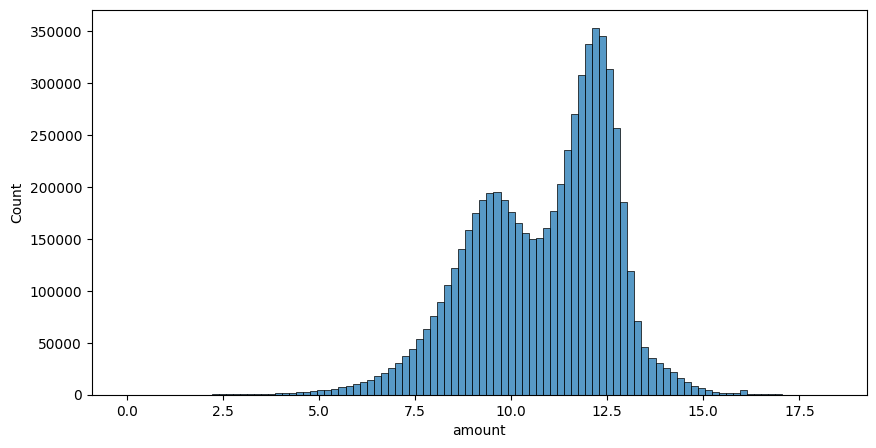

In [13]:
import numpy as np

plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(df["amount"]),
    bins=100
)

plt.show()

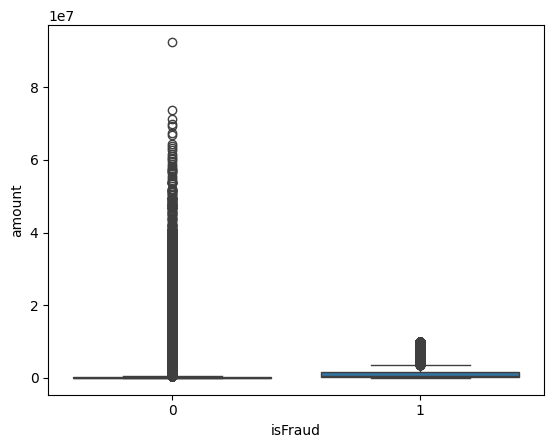

In [14]:
sns.boxplot(x="isFraud",
    y="amount",
    data=df
)

plt.show()

In [15]:
df["sender_balance_diff"] = ( df["oldbalanceOrg"] - df["newbalanceOrig"])

df["receiver_balance_diff"] = (df["newbalanceDest"]- df["oldbalanceDest"])

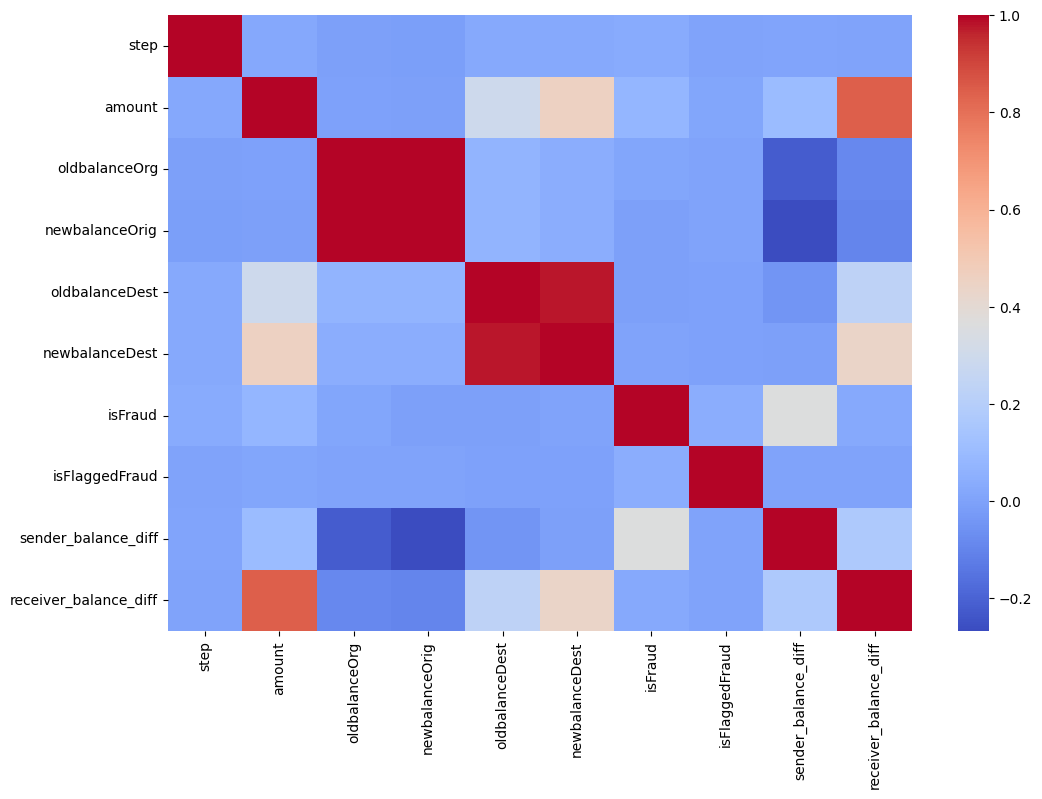

In [16]:
num_df = df.select_dtypes(include="number")

corr = num_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(corr, cmap="coolwarm")

plt.show()

In [17]:
sample_df = df.sample(n=200000,random_state=42)

sample_df.to_csv( "sample_paysim.csv", index=False)